<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

data_raw = pd.read_csv('/content/drive/MyDrive/Dataset Tugas Data Mining/train.csv')
data_val = pd.read_csv('/content/drive/MyDrive/Dataset Tugas Data Mining/test.csv')

data1 = data_raw.copy(deep = True)

data_cleaner = [data1, data_val]

print('kolom data Train dengan nilai NULL:\n', data1.isnull().sum())
print("-"*10)

print('kolom data Test dengan nilai NULL:\n', data_val.isnull().sum())
print("-"*10)

data_raw.describe(include = 'all')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
kolom data Train dengan nilai NULL:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------
kolom data Test dengan nilai NULL:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
----------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
for dataset in data_cleaner:
    # Isikan age yang kosong dengan median
    dataset['Age'].fillna(dataset['Age'].median(), inplace = True)

    # Isikan embarked dengan modus
    dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace = True)

    # Isikan fare dengan median
    dataset['Fare'].fillna(dataset['Fare'].median(), inplace = True)

# Hapus atribut cabin dan lainnya yang kita anggap tidak diperlukan
drop_column = ['PassengerId', 'Cabin', 'Ticket']
data1.drop(drop_column, axis=1, inplace = True)

print(data1.isnull().sum())
print("-" * 10)
print(data_val.isnull().sum())

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
----------
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


/tmp/ipykernel_353/31483882.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace = True)
/tmp/ipykernel_353/31483882.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [6]:
for dataset in data_cleaner:
    # Variables discrete
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

    dataset['IsAlone'] = 1 # Diisikan 1 jika sendiri
    dataset['IsAlone'].loc[dataset['FamilySize'] > 1] = 0 # Isikan 0 jika ada relasi yang bersama

    # Pisahkan title dari nama: https://www.phytonforbeginners.com/dictionary/phyton-split
    dataset['Title'] = dataset['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

    # Buat bin Fare menggunakan qcut atau bin Frekuensi:
    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)

    # Buat bin Age menggunakan cut atau nilai bin:
    dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)

# Bersihkan title yang jarang ada
stat_min = 10
title_names = (data1['Title'].value_counts() < stat_min)

data1['Title'] = data1['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)
print(data1['Title'].value_counts())
print("-" * 10)

# Tampilkan data lagi
data1.info()
data_val.info()
data1.sample(10)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Misc       27
Name: count, dtype: int64
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Name        891 non-null    object  
 3   Sex         891 non-null    object  
 4   Age         891 non-null    float64 
 5   SibSp       891 non-null    int64   
 6   Parch       891 non-null    int64   
 7   Fare        891 non-null    float64 
 8   Embarked    891 non-null    object  
 9   FamilySize  891 non-null    int64   
 10  IsAlone     891 non-null    int64   
 11  Title       891 non-null    object  
 12  FareBin     891 non-null    category
 13  AgeBin      891 non-null    category
dtypes: category(2), float64(2), int64(6), object(4)
memory usage: 85.9+ KB
<class 'pandas.core.frame.DataFram

/tmp/ipykernel_353/2955399611.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset['IsAlone'].loc[dataset['FamilySize'] > 1] = 0 # Isikan 0 jika ada relasi yang bersama
/tmp/ipykernel_353/2955399611.py:6: SettingWithCopyWarning: 
A va

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,FareBin,AgeBin
568,0,3,"Doharr, Mr. Tannous",male,28.0,0,0,7.2292,C,1,1,Mr,"(-0.001, 7.91]","(16.0, 32.0]"
408,0,3,"Birkeland, Mr. Hans Martin Monsen",male,21.0,0,0,7.7750,S,1,1,Mr,"(-0.001, 7.91]","(16.0, 32.0]"
689,1,1,"Madill, Miss. Georgette Alexandra",female,15.0,0,1,211.3375,S,2,0,Miss,"(31.0, 512.329]","(-0.08, 16.0]"
444,1,3,"Johannesen-Bratthammer, Mr. Bernt",male,28.0,0,0,8.1125,S,1,1,Mr,"(7.91, 14.454]","(16.0, 32.0]"
254,0,3,"Rosblom, Mrs. Viktor (Helena Wilhelmina)",female,41.0,0,2,20.2125,S,3,0,Mrs,"(14.454, 31.0]","(32.0, 48.0]"
310,1,1,"Hays, Miss. Margaret Bechstein",female,24.0,0,0,83.1583,C,1,1,Miss,"(31.0, 512.329]","(16.0, 32.0]"
154,0,3,"Olsen, Mr. Ole Martin",male,28.0,0,0,7.3125,S,1,1,Mr,"(-0.001, 7.91]","(16.0, 32.0]"
555,0,1,"Wright, Mr. George",male,62.0,0,0,26.5500,S,1,1,Mr,"(14.454, 31.0]","(48.0, 64.0]"
64,0,1,"Stewart, Mr. Albert A",male,28.0,0,0,27.7208,C,1,1,Mr,"(14.454, 31.0]","(16.0, 32.0]"
239,0,2,"Hunt, Mr. George Henry",male,33.0,0,0,12.2750,S,1,1,Mr,"(7.91, 14.454]","(32.0, 48.0]"


In [8]:
# Discrete Variable Correlation dengan Survival menggunakan
# group by / pivot table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html

Target = ['Survived']
data1_x = ['Sex', 'Pclass', 'Embarked', 'Title', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']

for x in data1_x:
    if data1[x].dtype != 'float64' :
        print('Korelasi Survival dengan:', x)
        print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
        print('-'*10, '\n')

# Menggunakan crosstabs: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.crosstab.html
print(pd.crosstab(data1['Title'], data1[Target[0]]))

Korelasi Survival dengan: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Korelasi Survival dengan: Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
---------- 

Korelasi Survival dengan: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
---------- 

Korelasi Survival dengan: FamilySize
   FamilySize  Survived
0           1  0.303538
1           2  0.552795
2           3  0.578431
3           4  0.724138
4           5  0.200000
5           6  0.136364
6           7  0.333333
7           8  0.000000
8          11  0.000000
---------- 

Korelasi Survival dengan: IsAlone
   IsAlone  Survived
0        0  0.505650
1        1  0.303538
---------- 

Korelasi Survival dengan: Title
    Title  Survived
0  Master  0.575000
1    Misc  0.444444
2    Miss  0.697802
3      Mr  0.156673
4     Mrs  0.792000
---------- 

Korelasi Survival dengan: FareBin
           FareBin  Survived
0   (-0.001

/tmp/ipykernel_353/3242084041.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
/tmp/ipykernel_353/3242084041.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())


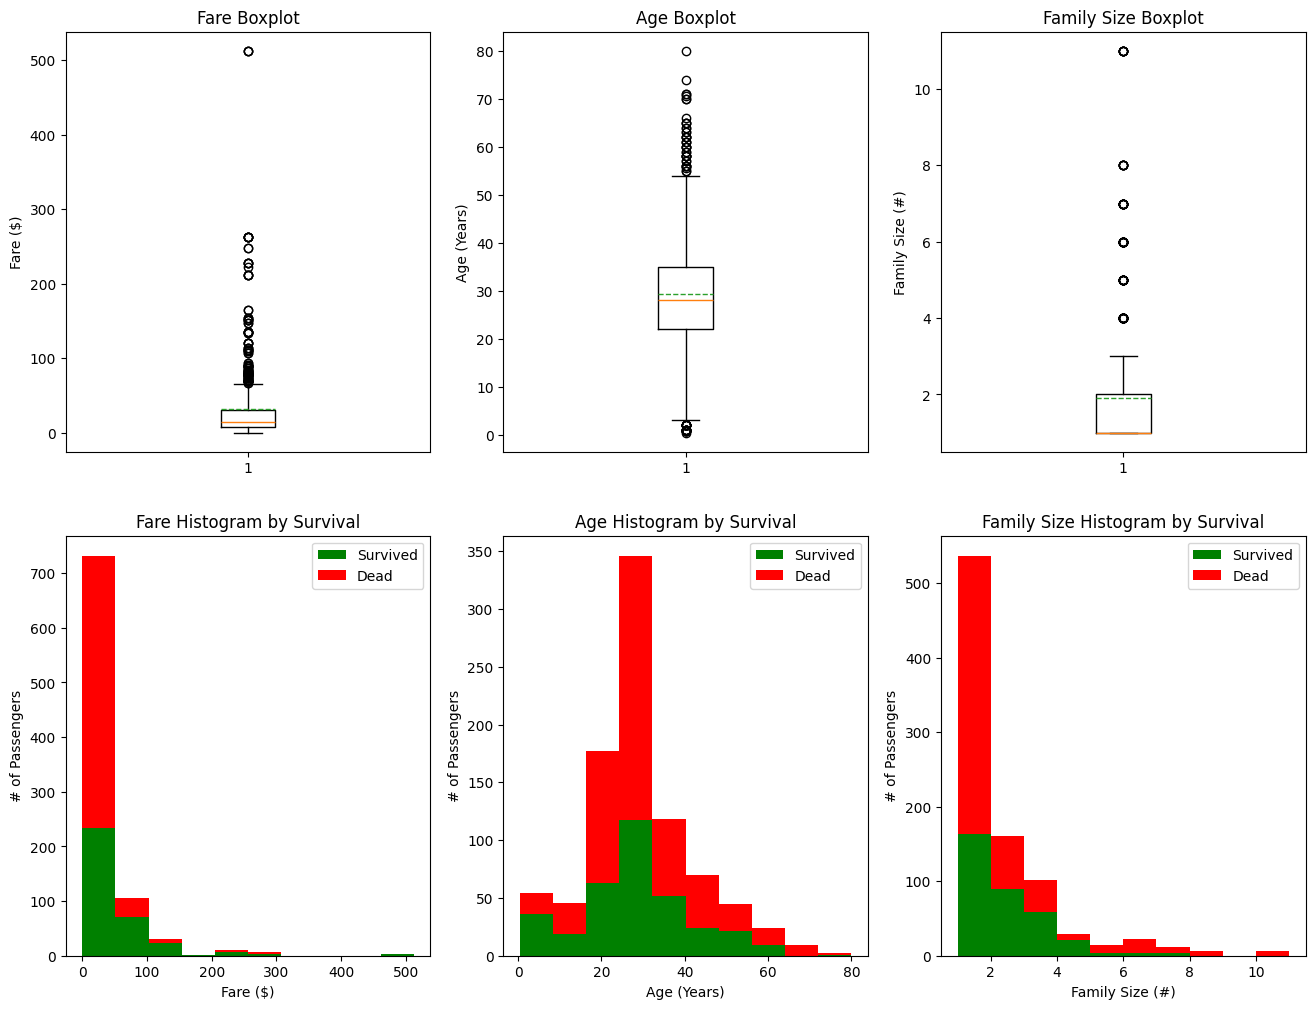

In [9]:
plt.figure(figsize=[16,12])
plt.subplot(231)
plt.boxplot(x=data1['Fare'], showmeans = True, meanline = True)
plt.title('Fare Boxplot')
plt.ylabel('Fare ($)')

plt.subplot(232)
plt.boxplot(data1['Age'], showmeans = True, meanline = True)
plt.title('Age Boxplot')
plt.ylabel('Age (Years)')

plt.subplot(233)
plt.boxplot(data1['FamilySize'], showmeans = True, meanline = True)
plt.title('Family Size Boxplot')
plt.ylabel('Family Size (#)')

plt.subplot(234)
plt.hist(x = [data1[data1['Survived']==1]['Fare'], data1[data1['Survived']==0]['Fare']],
         stacked=True, color = ['g','r'], label = ['Survived','Dead'])
plt.title('Fare Histogram by Survival')
plt.xlabel('Fare ($)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(235)
plt.hist(x = [data1[data1['Survived']==1]['Age'], data1[data1['Survived']==0]['Age']],
         stacked=True, color = ['g','r'], label = ['Survived','Dead'])
plt.title('Age Histogram by Survival')
plt.xlabel('Age (Years)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(236)
plt.hist(x = [data1[data1['Survived']==1]['FamilySize'], data1[data1['Survived']==0]['FamilySize']],
         stacked=True, color = ['g','r'], label = ['Survived','Dead'])
plt.title('Family Size Histogram by Survival')
plt.xlabel('Family Size (#)')
plt.ylabel('# of Passengers')
plt.legend()

<Axes: xlabel='FamilySize', ylabel='Survived'>

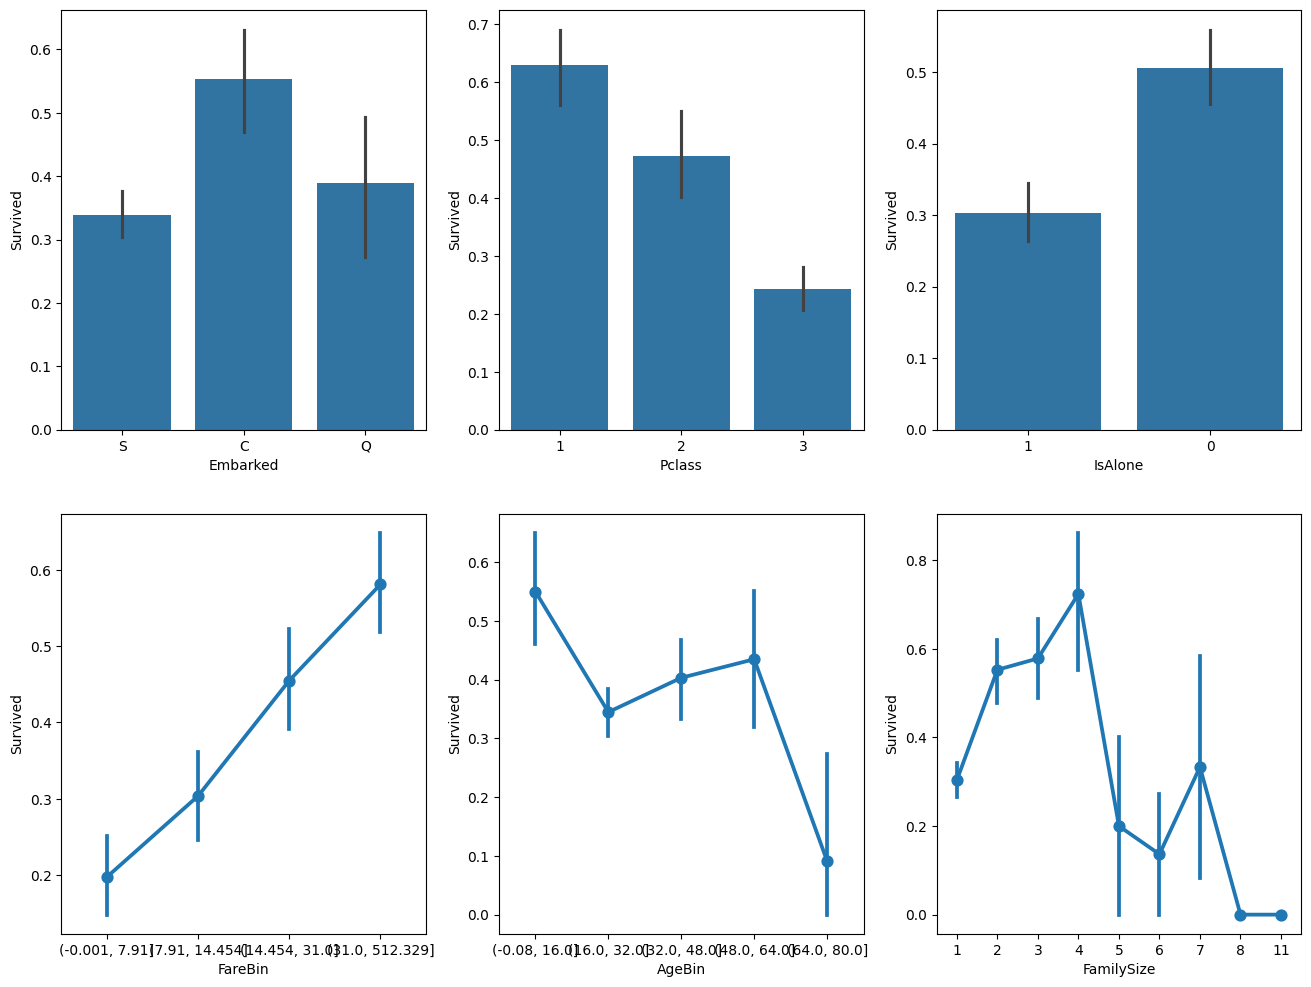

In [10]:
#kita gunakan seaborn untuk perbandingan antar variabel: https://seaborn.pydata.org/api.html
#graph individual features dengan survival
fig, saxis = plt.subplots(2, 3, figsize=(16,12))

sns.barplot(x = 'Embarked', y = 'Survived', data=data1, ax = saxis[0,0])
sns.barplot(x = 'Pclass', y = 'Survived', order=[1,2,3], data=data1, ax = saxis[0,1])
sns.barplot(x = 'IsAlone', y = 'Survived', order=[1,0], data=data1, ax = saxis[0,2])

sns.pointplot(x = 'FareBin', y = 'Survived', data=data1, ax = saxis[1,0])
sns.pointplot(x = 'AgeBin', y = 'Survived', data=data1, ax = saxis[1,1])
sns.pointplot(x = 'FamilySize', y = 'Survived', data=data1, ax = saxis[1,2])

Text(0.5, 1.0, 'Perbandingan Survival Pclass vs Family Size')

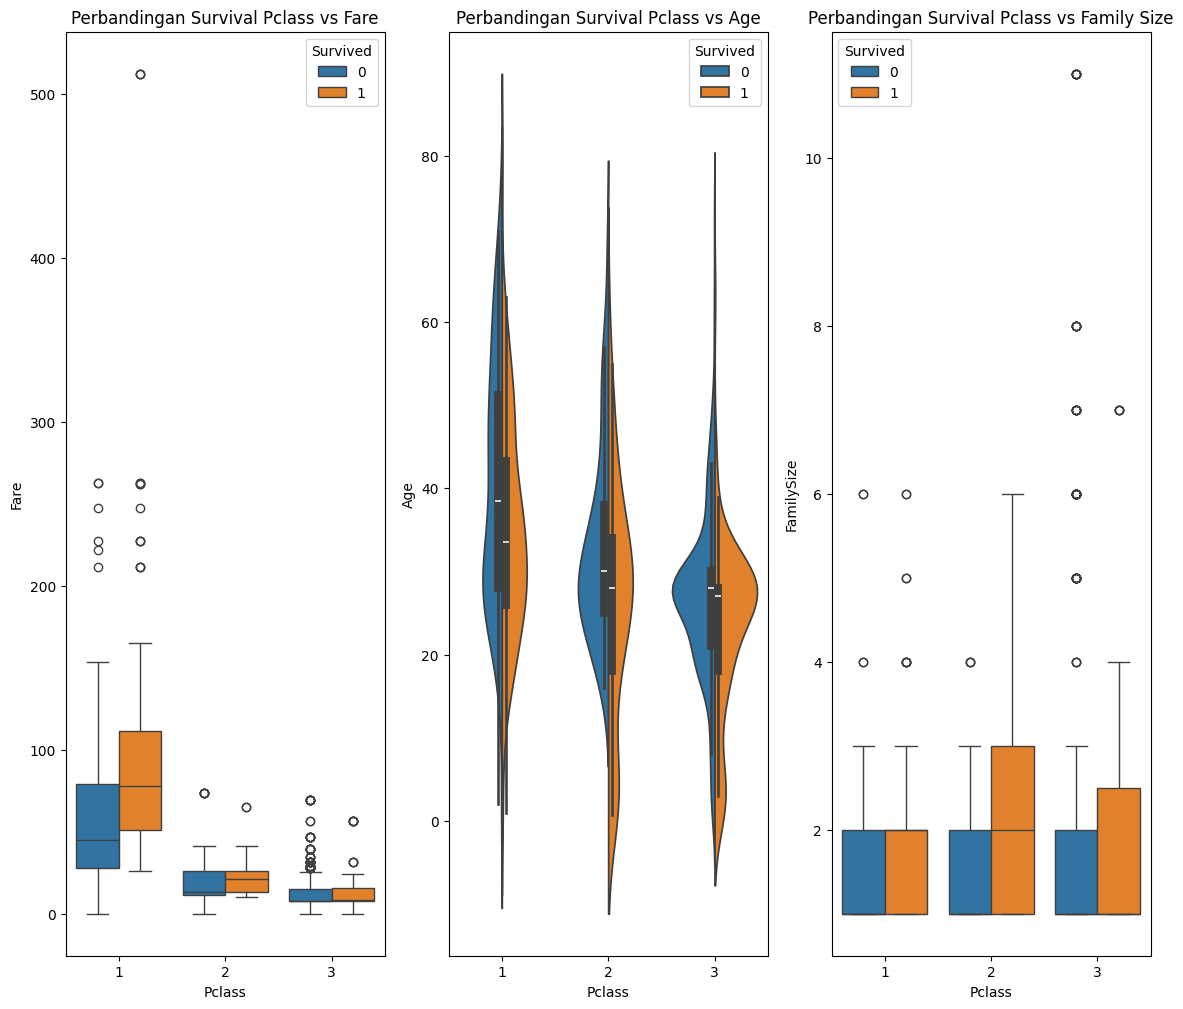

In [11]:
#grafik distribusi dari data kualitatif, Pclass
#Pclass  cukup tinggi korelasinya dengan survival, berikut akan ditunjukkan perbandingan Pclass dengan beberapa fitur lain
fig, (axis1,axis2,axis3) = plt.subplots(1,3,figsize=(14,12))

sns.boxplot(x = 'Pclass', y = 'Fare', hue = 'Survived', data = data1, ax = axis1)
axis1.set_title('Perbandingan Survival Pclass vs Fare')

sns.violinplot(x = 'Pclass', y = 'Age', hue = 'Survived', data = data1, split = True, ax = axis2)
axis2.set_title('Perbandingan Survival Pclass vs Age')

sns.boxplot(x = 'Pclass', y = 'FamilySize', hue = 'Survived', data = data1, ax = axis3)
axis3.set_title('Perbandingan Survival Pclass vs Family Size')

<Axes: xlabel='Pclass', ylabel='Survived'>

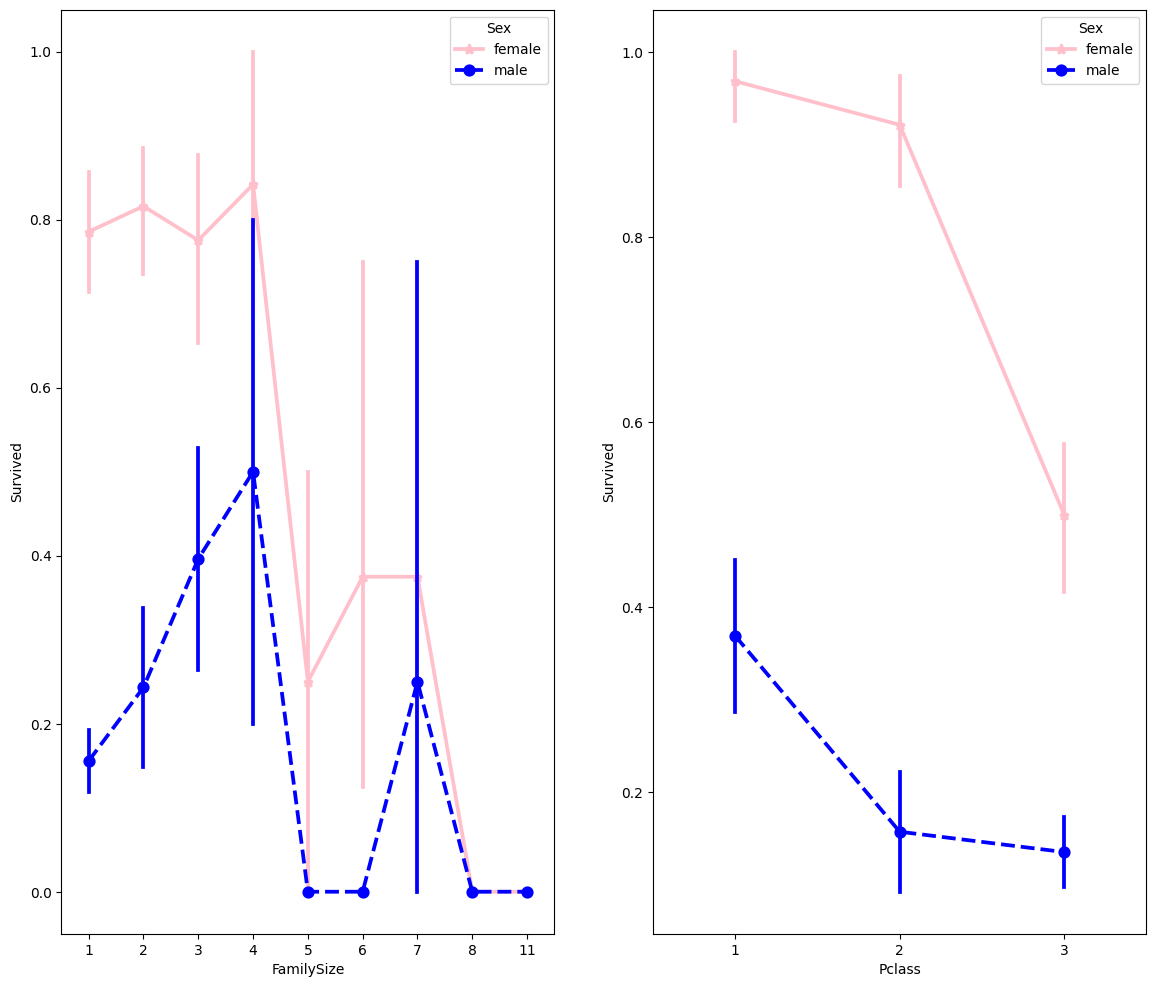

In [12]:
#contoh grafik perbandingan lainnya
fig, (maxis1, maxis2) = plt.subplots(1, 2, figsize=(14,12))

#bagaimana pengaruh faktor ukuran keluarga terhadap perbandingan jenis kelamin dan survival
sns.pointplot(x="FamilySize", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax = maxis1)

#bagaimana perbandingan pengaruh faktor class terhadap perbandingan jenis kelamin dan survival
sns.pointplot(x="Pclass", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax = maxis2)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95.0)` for the same effect.

  func(*plot_args, **plot_kwargs

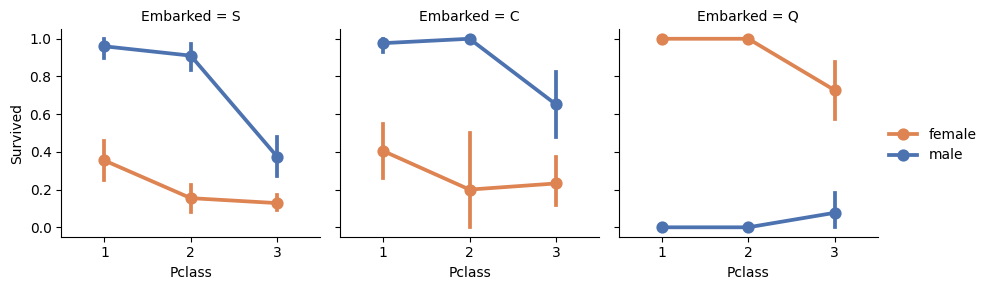

In [14]:
#bagaimana pengaruh faktor port keberangkatan terhadap perbandingan Pclass, Sex, dan survival
#facetgrid: https://seaborn.pydata.org/generated/seaborn.FacetGrid.html
e = sns.FacetGrid(data1, col = 'Embarked')
e.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', ci=95.0, palette = 'deep')
e.add_legend()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


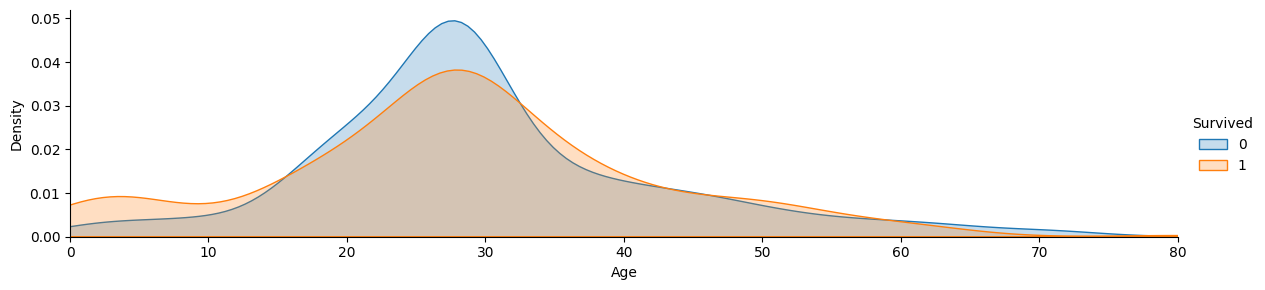

In [15]:
# plot distribusi dari usia penumpang yang selamat / tidak selamat
a = sns.FacetGrid( data1, hue = 'Survived', aspect=4 )
a.map(sns.kdeplot, 'Age', shade= True )
a.set(xlim=(0 , data1['Age'].max()))
a.add_legend()

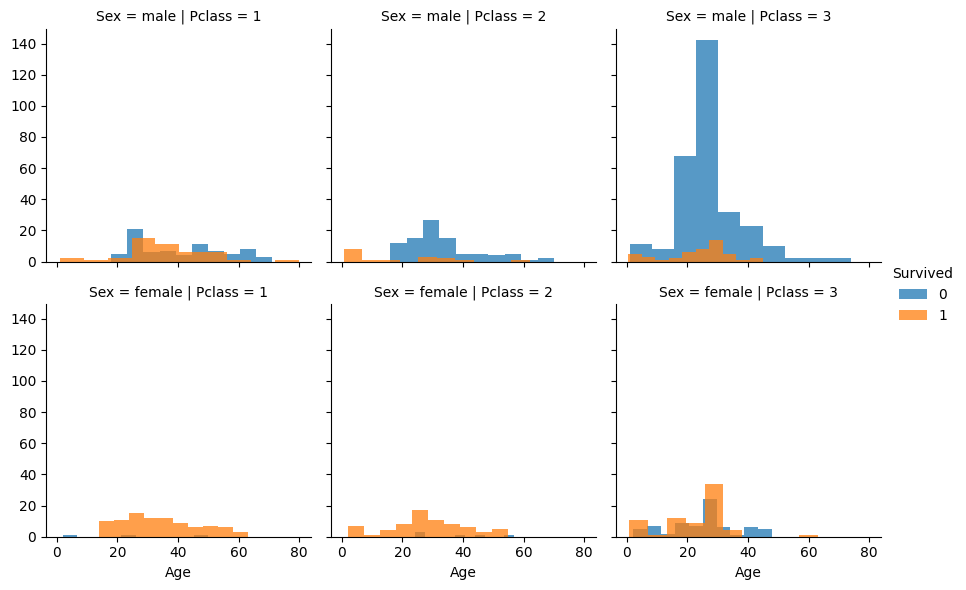

In [16]:
# perbandingan histogram dari sex, class, dan age dengan survival
h = sns.FacetGrid(data1, row = 'Sex', col = 'Pclass', hue = 'Survived')
h.map(plt.hist, 'Age', alpha = .75)
h.add_legend()

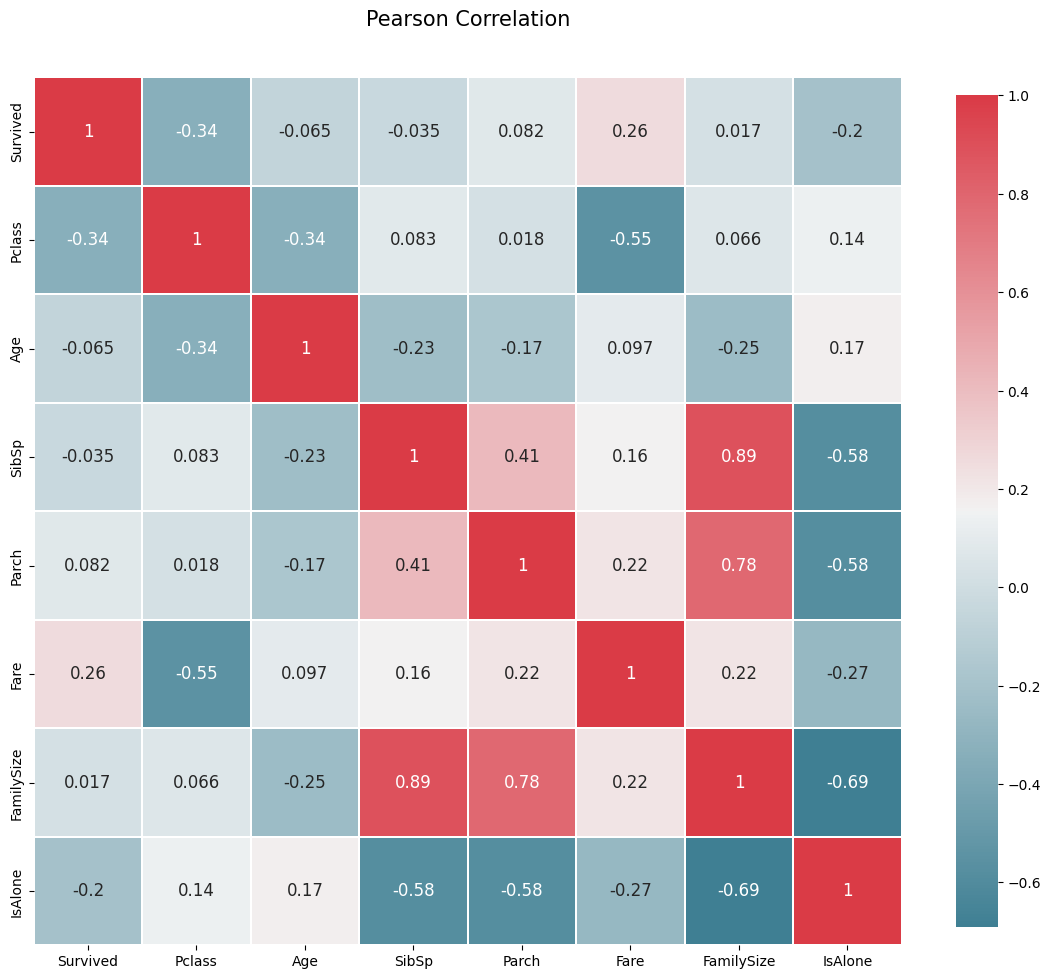

In [17]:
# Korelasi heatmap dari dataset
def correlation_heatmap(df):
    _ , ax = plt.subplots(figsize =(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap = True)

    #hanya dipilih fitur numerik saja
    numerical_df = df.select_dtypes(include=['number'])

    _ = sns.heatmap(
        numerical_df.corr(),
        cmap = colormap,
        square=True,
        cbar_kws={'shrink':.9 },
        ax=ax,
        annot=True,
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize':12 }
    )
    plt.title('Pearson Correlation', y=1.05, size=15)

correlation_heatmap(data1)

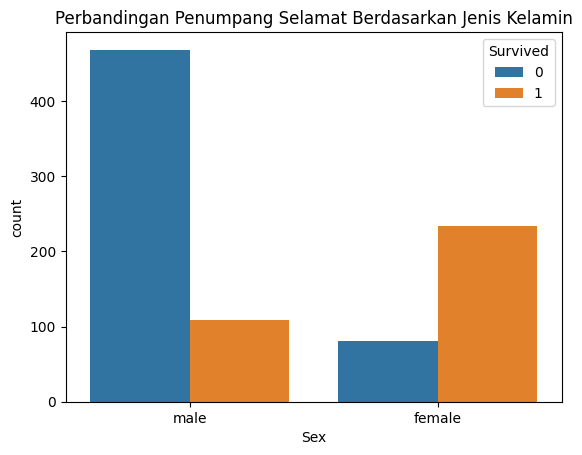

In [21]:
train = data1

sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Perbandingan Penumpang Selamat Berdasarkan Jenis Kelamin')
plt.show()

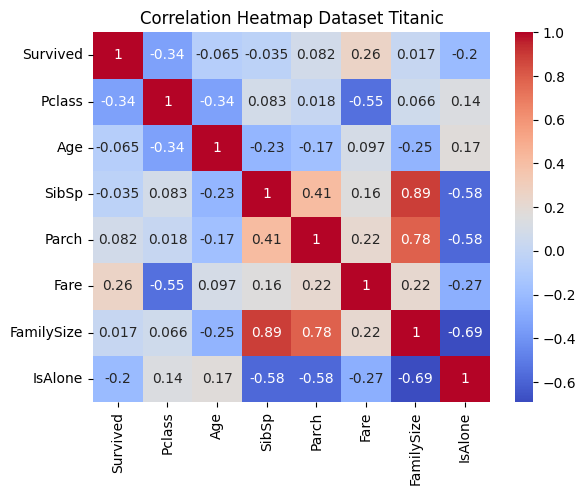

In [22]:
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap Dataset Titanic')
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db = pd.read_csv('/content/drive/MyDrive/Dataset Tugas Data Mining/diabetes.csv')

db.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
db.info()
db.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
(db == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [30]:
column = ['Pregnancies', 'Glucose','BloodPressure','SkinThickness','Insulin','BMI', 'Outcome']

for col in column:
    db[col] = db[col].replace(0, db[col].median())

(db == 0).sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,500


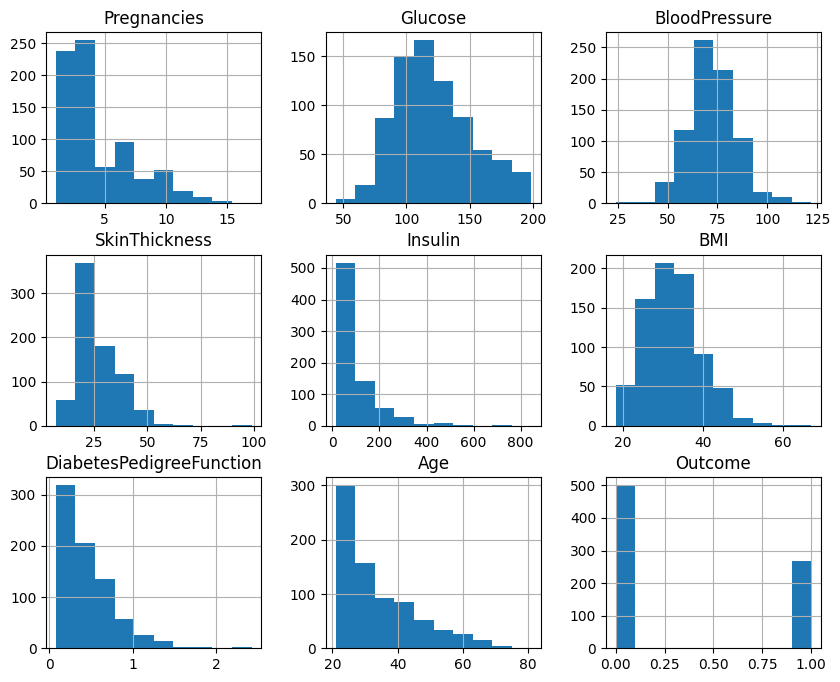

In [31]:
db.hist(figsize=(10,8))
plt.show()

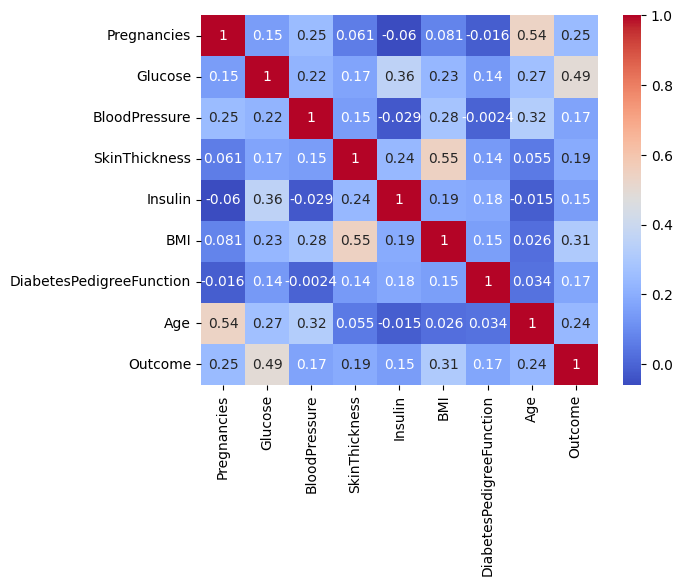

In [32]:
sns.heatmap(db.corr(), annot=True, cmap='coolwarm')
plt.show()

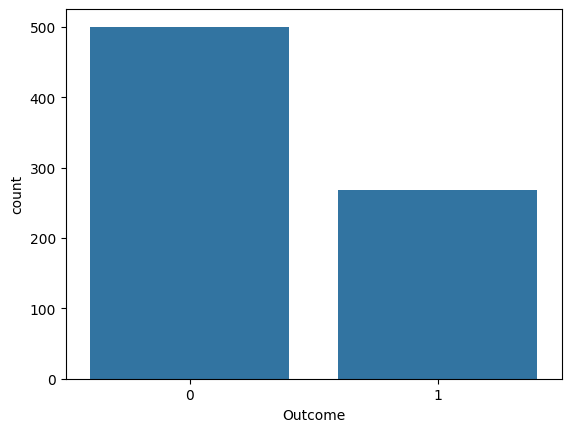

In [33]:
sns.countplot(x='Outcome', data=db)
plt.show()